# Lung Sound Classification (HLS-CMDS)

Classifies **lung sound type** (Normal, Wheezing, Rhonchi, Coarse/Fine Crackles, Pleural Rub) from the [HLS-CMDS](https://doi.org/10.1109/IEEEDATA.2025.3566012) recordings, using a CNN trained on log-mel spectrograms.

## Setup

Imports: `pathlib` for file globbing, `pandas` to read the label CSVs, `librosa`/`numpy` for audio loading and feature extraction, `sklearn` for the train/test split and evaluation metrics, and `torch` for the CNN and training loop.

In [1]:
from pathlib import Path
from collections import Counter

import numpy as np, pandas as pd, librosa, torch
import matplotlib.pyplot as plt
from torch import nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

## Configuration

`ROOT` points at the `HLS-CMDS/` dataset folder (see `README.md` for the download/layout instructions — it's gitignored because of the `.wav` files). Audio is resampled to `SAMPLE_RATE=8000` Hz and every clip is fixed to `SECS=6.0` s so all spectrograms come out the same shape; `N_MELS`/`N_FFT`/`HOP` control the mel-spectrogram resolution.

In [2]:
ROOT = Path("HLS-CMDS")
SAMPLE_RATE = 8000
HOP_LENGTH = 256
SECS = 10.0
N_MELS = 64
LENGTH_OF_FFT = 1024
RANDOM_STATE = 42

## Build the file index

Lung-labeled recordings come from two places: `LS/LS/*.wav` and the `L####.wav` files inside `Mix/Mix/` (the isolated lung component of each mixed recording, labeled by `Mix.csv`'s `Lung Sound ID`/`Lung Sound Type` columns, e.g. `L0001.wav`). Combining both sources gives 195 samples across 6 balanced classes instead of just the 50 in `LS.csv` alone.

Note: `LS.csv`'s own `Lung Sound ID` column doesn't reliably match the real filenames — it abbreviates Coarse Crackles as `G` and Fine Crackles as `C` (e.g. `M_G_LLA`), while the actual `.wav` files on disk use `CC`/`FC` (e.g. `M_CC_LLA.wav`). So for `LS/LS/` we decode the label directly from the filename's own code via a fixed `CODE2TYPE` table instead of joining on that ID column; `Mix.csv`'s numeric IDs (`L0001`, ...) don't have this problem and are looked up normally.

`CLASSES` is the sorted set of the 6 lung sound types, and `LABEL2IDX` maps each type name to the integer index used for training.

In [3]:
CODE2TYPE = {
    "N": "Normal", 
    "CC": "Coarse Crackles", 
    "FC": "Fine Crackles",
    "R": "Rhonchi", 
    "W": "Wheezing", 
    "PR": "Pleural Rub"
    }
mix_type = pd.read_csv(ROOT/"Mix.csv").set_index("Lung Sound ID")["Lung Sound Type"]

CLASSES = sorted(CODE2TYPE.values())
LABEL2IDX = {c: i for i, c in enumerate(CLASSES)}

def build_index():
    recs = [(wav, LABEL2IDX[CODE2TYPE[wav.stem.split("_")[1]]]) for wav in (ROOT/"LS"/"LS").glob("*.wav")]
    recs += [(wav, LABEL2IDX[mix_type[wav.stem]]) for wav in (ROOT/"Mix"/"Mix").glob("L*.wav")]
    return recs

## Feature extraction

`to_melspec` turns a `.wav` file into a normalized log-mel spectrogram:

1. Load audio mono at `SAMPLE_RATE` and center-crop or zero-pad it to exactly `SECS` seconds, so every clip yields a fixed-size input.
2. Compute a mel-spectrogram and convert power to decibels (`power_to_db`).
3. Standardize (zero mean, unit variance) so all clips are on a comparable scale.

A CNN uses the full 2-D spectrogram instead of collapsing it to a flat feature vector. This lets the model learn local time-frequency patterns that may separate lung sound classes such as wheezing, rhonchi, crackles, and pleural rub.

In [4]:
def to_melspec(path):
    y, _ = librosa.load(path, sr=SAMPLE_RATE, mono=True)
    n = int(SECS*SAMPLE_RATE)
    y = np.pad(y, (0, n-len(y))) if len(y) < n else y[(len(y)-n)//2:(len(y)-n)//2+n]
    mel = librosa.feature.melspectrogram(y=y, sr=SAMPLE_RATE, n_fft=LENGTH_OF_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS)
    m = librosa.power_to_db(mel, ref=np.max)
    return ((m - m.mean()) / (m.std() + 1e-6)).astype(np.float32)

## Dataset

Thin `torch.utils.data.Dataset` wrapper: given a list of `(path, label)` pairs (from `build_index`), it lazily computes the log-mel spectrogram per item and returns it as a `(1, N_MELS, time)` float tensor plus its integer class label, ready for a `DataLoader`/CNN.

In [5]:
class LungSounds(Dataset):
    def __init__(self, recs):
        self.recs = recs
    def __len__(self): return len(self.recs)
    def __getitem__(self, i):
        path, label = self.recs[i]
        return torch.from_numpy(to_melspec(path)).unsqueeze(0), label

In [6]:
recs = build_index()
print(Counter(CLASSES[l] for _, l in recs))
print("spectrogram shape:", LungSounds(recs)[0][0].shape)

Counter({'Normal': 40, 'Wheezing': 35, 'Pleural Rub': 34, 'Rhonchi': 31, 'Coarse Crackles': 28, 'Fine Crackles': 27})
spectrogram shape: torch.Size([1, 64, 313])


## Duplicate recordings retained

This copy keeps all 195 lung recordings, including acoustically duplicate clips, so the CNN trains on the full lung-only dataset.


In [7]:
print(f"Keeping all {len(recs)} lung recordings, including duplicates.")


Keeping all 195 lung recordings, including duplicates.


## Convolutional Neural Network (PyTorch)

The CNN receives each spectrogram as a one-channel image-like tensor. Convolution layers learn local patterns across frequency and time, then adaptive average pooling reduces the learned feature maps before the final class prediction.

In [8]:
class LungCNN(nn.Module):
    def __init__(self, num_classes=len(CLASSES)):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.30),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

## Train/test split

The split is stratified so each class keeps approximately the same proportion in training and testing. The small dataset makes this important: without stratification, a rare class could be underrepresented in the test set.

In [9]:
labels = [label for _, label in recs]
train_recs, test_recs = train_test_split(
    recs,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=labels,
)

train_loader = DataLoader(LungSounds(train_recs), batch_size=16, shuffle=True)
test_loader = DataLoader(LungSounds(test_recs), batch_size=32, shuffle=False)

print(f"train samples: {len(train_recs)}")
print(f"test samples:  {len(test_recs)}")

train samples: 146
test samples:  49


## Training loop

`CrossEntropyLoss` is used because this is a multi-class classification problem. The CNN outputs raw logits, and the loss function internally applies the softmax operation needed for class probabilities.

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = LungCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

def run_epoch(loader, training):
    model.train(training)
    total_loss, correct, total = 0.0, 0, 0

    for x, y in loader:
        x = x.to(device).float()
        y = y.to(device).long()

        with torch.set_grad_enabled(training):
            logits = model(x)
            loss = criterion(logits, y)

            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        total_loss += loss.item() * x.size(0)
        correct += (logits.argmax(dim=1) == y).sum().item()
        total += y.size(0)

    return total_loss / total, correct / total

history = []
EPOCHS = 100
PATIENCE = 10
best_test_acc = 0.0
best_epoch = 0
best_state = None
epochs_without_improvement = 0

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = run_epoch(train_loader, training=True)
    test_loss, test_acc = run_epoch(test_loader, training=False)
    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "test_loss": test_loss,
        "test_acc": test_acc,
    })

    if test_acc > best_test_acc:
        best_test_acc = test_acc
        best_epoch = epoch
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epoch == 1 or epoch % 10 == 0:
        print(
            f"epoch {epoch:03d} | "
            f"train loss {train_loss:.3f}, acc {train_acc:.3f} | "
            f"test loss {test_loss:.3f}, acc {test_acc:.3f} | "
            f"best test acc {best_test_acc:.3f} at epoch {best_epoch}"
        )

    if epochs_without_improvement >= PATIENCE:
        print(f"Early stopping at epoch {epoch}; best test acc {best_test_acc:.3f} at epoch {best_epoch}")
        break

if best_state is not None:
    model.load_state_dict(best_state)
    model.to(device)

epoch 001 | train loss 1.811, acc 0.205 | test loss 1.781, acc 0.184 | best test acc 0.184 at epoch 1
epoch 010 | train loss 1.518, acc 0.473 | test loss 1.503, acc 0.408 | best test acc 0.531 at epoch 5
epoch 020 | train loss 1.144, acc 0.767 | test loss 1.236, acc 0.673 | best test acc 0.694 at epoch 16
epoch 030 | train loss 0.952, acc 0.795 | test loss 1.000, acc 0.673 | best test acc 0.837 at epoch 26
Early stopping at epoch 36; best test acc 0.837 at epoch 26


## Evaluation

The final cells report per-class precision/recall/F1, plot training curves, and show a labeled confusion matrix. These are more useful than accuracy alone because the dataset is small and the model may perform better on some lung sound types than others.

In [11]:
model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for x, y in test_loader:
        logits = model(x.to(device).float())
        preds = logits.argmax(dim=1).cpu().numpy()
        y_pred.extend(preds.tolist())
        y_true.extend(y.numpy().tolist())

cm = confusion_matrix(y_true, y_pred)
print(classification_report(y_true, y_pred, target_names=CLASSES, zero_division=0))

                 precision    recall  f1-score   support

Coarse Crackles       0.86      0.86      0.86         7
  Fine Crackles       1.00      0.57      0.73         7
         Normal       0.83      1.00      0.91        10
    Pleural Rub       0.62      0.62      0.62         8
        Rhonchi       0.80      1.00      0.89         8
       Wheezing       1.00      0.89      0.94         9

       accuracy                           0.84        49
      macro avg       0.85      0.82      0.82        49
   weighted avg       0.85      0.84      0.83        49



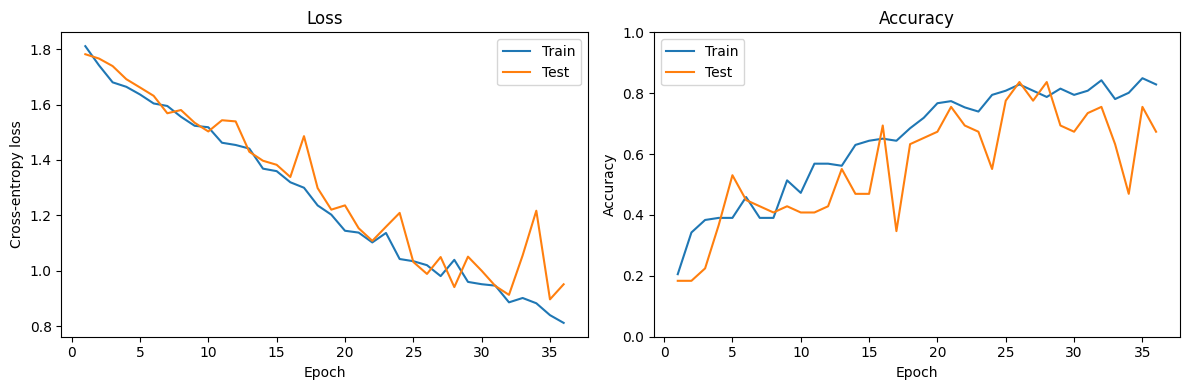

In [12]:
history_df = pd.DataFrame(history)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_df["epoch"], history_df["train_loss"], label="Train")
axes[0].plot(history_df["epoch"], history_df["test_loss"], label="Test")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-entropy loss")
axes[0].legend()

axes[1].plot(history_df["epoch"], history_df["train_acc"], label="Train")
axes[1].plot(history_df["epoch"], history_df["test_acc"], label="Test")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0, 1)
axes[1].legend()

plt.tight_layout()
plt.show()

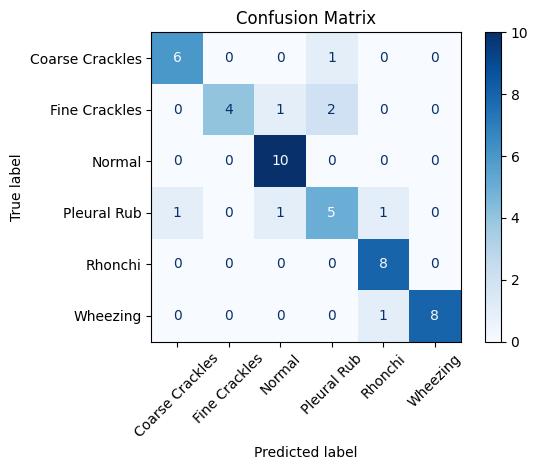

In [13]:
ConfusionMatrixDisplay(cm, display_labels=CLASSES).plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()